A Prepayment modelling demo, which shows dynamics of pool cash flow for 10 months.
pipline starting from mortgage level prepayment rate for each month to pool level prepayment rate.

some configurations:

Part 1: 
1. constant market rate
2. a pool of 10 mortgages
3. pre-set logistic model with 3 factors(Incentive, SeasoningEffect, LTVEffect) for single mortgage
4. if prepayment happen, then it is full prepayment.
5. single pool of mortgages, no new pool for new months.

Part 2:
1. dynamic market rate( simulated via monte carlo, and Hull-White model)
2. the rest same as Part 1

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#gloabal variables and functions

In [151]:

r_market=5.4/100

loan_id=list(range(1,11))
Orig_Balance=[100,120,90,150,80,110,50,130,95,140]
r_mort=[x/100 for x in [6.5,7,3,4,5,2,9,5.5,3,4.5]]
Orig_Term=[60 for _ in range(0,10)]
Remaining_Term=[59,56,58,30,20,57,40,48,55,58]
LTV=[x/100 for x in [80,70,90,60,50,20,90,55,30,45]]

# initial pool, each month end, it will change
pool_mortgages = pd.DataFrame({'loanID':loan_id,
                               'Orig_Balance' : Orig_Balance,
                               'r_mort':r_mort,
                               'Orig_Term' : Orig_Term,
                               'Remaining_Term':Remaining_Term,
                               'LTV':LTV,
                               'Type':"fixed"})
pool_mortgages['Seasoning'] = pool_mortgages['Orig_Term'] - pool_mortgages['Remaining_Term']

In [152]:
pool_mortgages

,loanID,Orig_Balance,r_mort,Orig_Term,Remaining_Term,LTV,Type,Seasonging
0,1,100,0.065,60,59,0.80,fixed,1
1,2,120,0.070,60,56,0.70,fixed,4
2,3,90,0.030,60,58,0.90,fixed,2
3,4,150,0.040,60,30,0.60,fixed,30
4,5,80,0.050,60,20,0.50,fixed,40
5,6,110,0.020,60,57,0.20,fixed,3
6,7,50,0.090,60,40,0.90,fixed,20
7,8,130,0.055,60,48,0.55,fixed,12
8,9,95,0.030,60,55,0.30,fixed,5
9,10,140,0.045,60,58,0.45,fixed,2


In [153]:
def level_payment(balance: float, month_rate: float, remaining_term: int) -> float:
    """
    given balance, monthly rate, remaining term(months), 
    return the monthly payment
    """
    if balance <= 0:
        return 0.0

    if abs(month_rate) < 1e-12:
        return balance / remaining_term  # zero-rate case

    return balance * (month_rate * (1 + month_rate) ** remaining_term) / ((1 + month_rate) ** remaining_term - 1)

In [154]:
def prepayment_loan(r_mort,r_market,seasoning,ltv):
    """
    a naiive logistic model with 3 factor,
    and a threadhold,
    return boolen, indicate whether the single loan will have prepayment or not.
    """
    Incentive = np.max(r_mort - r_market,0)
    incentive_eff = max(Incentive - 0.005, 0.0)

    # Seasoning ramps up over first 24 months, then saturates
    seasoning_eff = min(seasoning / 12, 1.0)
    z = (
        -3
        + 40.0 * incentive_eff            # strong driver
        + 2 * seasoning_eff            # seasoning increases likelihood
        - 1.5 * max(ltv - 0.70, 0.0)  # high LTV reduces refinancing ability
    )
    p = 1/(1+ np.exp(-z))
    threadhold = 0.6
    return p > threadhold

In [155]:
def generate_cashflow_with_full_prepay(
    loan_id: int,
    balance: float,
    annual_rate: float,
    remaining_term: int,
    ltv: float,
    seasoning: int,
    market_rate: float,
    months: int = 3,
):
    """
    for each single loan, generate cash flow for next 3 month end,
    if prepayment happen, assume it to be full prepayment
    """

    rows = []
    current_balance = balance
    current_term = remaining_term
    current_seasoning = seasoning
    prepaid_already = False

    for month in range(1, months + 1):

        # If already prepaid → everything is zero
        if prepaid_already or current_balance <= 1e-12 or current_term <= 0:
            rows.append({
                "loan_id": loan_id,
                "month": month,
                "opening_balance": current_balance,
                "scheduled_payment": 0.0,
                "interest": 0.0,
                "scheduled_principal": 0.0,
                "full_prepay_event": False,
                "prepay_principal": 0.0,
                "total_cashflow": 0.0,
                "closing_balance": 0.0,
            })
            current_balance = 0.0
            continue

        # --- Step 1: scheduled cashflow ---
        monthly_rate = annual_rate / 12.0

        monthly_payment= level_payment(current_balance, monthly_rate, current_term)

        interest = current_balance * monthly_rate
        scheduled_principal = monthly_payment - interest
        scheduled_principal = min(scheduled_principal, current_balance)

        balance_after_sched = current_balance - scheduled_principal

        # --- Step 2: prepayment model ---
        full_prepay_event = prepayment_loan(
            r_mort=annual_rate,
            r_market=market_rate,
            seasoning=current_seasoning,
            ltv=ltv,
        )

        # --- Step 3: apply prepayment ---
        if full_prepay_event:
            prepay_principal = balance_after_sched
            closing_balance = 0.0
            prepaid_already = True
        else:
            prepay_principal = 0.0
            closing_balance = balance_after_sched

        # --- Step 4: total cashflow ---
        total_cashflow = interest + scheduled_principal + prepay_principal

        # --- Step 5: store results ---
        rows.append({
            "loan_id": loan_id,
            "month": month,
            "opening_balance": round(current_balance, 6),
            "scheduled_payment": round(monthly_payment, 6),
            "interest": round(interest, 6),
            "scheduled_principal": round(scheduled_principal, 6),
            "full_prepay_event": full_prepay_event,
            "prepay_principal": round(prepay_principal, 6),
            "total_cashflow": round(total_cashflow, 6),
            "closing_balance": round(closing_balance, 6),
        })

        # --- Step 6: update state ---
        current_balance = closing_balance
        current_term -= 1
        current_seasoning += 1

    return pd.DataFrame(rows)

In [156]:
def pool_cf(pool_morts, market_rate, months=3):
    """
    given pool of mortgages,
    for each mortgage, it simulate the cash flow for 3 month,
    return the concated pd of cash flow of each mortgage
    """
    lst_df = []
    for row in pool_morts.itertuples(index=True):
        loan_id= row[1]
        balance = float(row[2])
        annual_rate=float(row[3])
        remaining_term = float(row[5])
        ltv=float(row[6])
        seasoning = float(row[-1])

        lst_df.append(generate_cashflow_with_full_prepay(loan_id,balance,annual_rate,
                                    remaining_term,ltv,seasoning,
                                    market_rate,months))
        
    return pd.concat(lst_df, axis=0, ignore_index=True)

In [157]:
def hull_white_mc(n_path, n_steps, T, r0, a, sigma, theta_fn=None, seed=None):
    """
    Simulate short-rate paths under the 1-factor Hull-White model:
        dr(t) = [theta(t) - a*r(t)] dt + sigma dW(t)

    Parameters
    ----------
    n_path : int
        Number of Monte Carlo paths.
    n_steps : int
        Number of time steps.
    T : float
        Horizon in years.
    r0 : float
        Initial short rate.
    a : float
        Mean reversion speed.
    sigma : float
        Volatility.
    theta_fn : callable or None
        Function theta(t). If None, uses 0.03
    seed : int or None
        Random seed.

    Returns
    -------
    times : np.ndarray
        Time grid.
    paths : np.ndarray
        Simulated short-rate paths, shape (n_path, n_steps + 1).
    """
    if seed is not None:
        np.random.seed(seed)

    if theta_fn is None:
        theta_fn = lambda t: 0.1

    dt = T / n_steps
    times = np.linspace(0.0, T, n_steps + 1)

    paths = np.zeros((n_path, n_steps + 1))
    paths[:, 0] = r0

    for i in range(n_steps):
        t = times[i]
        theta_t = theta_fn(t)
        z = np.random.normal(loc=0,scale=np.sqrt(dt),size=n_path)

        # Euler discretization of Hull-White short rate
        dr = (theta_t - a * paths[:, i]) * dt + sigma * z
        paths[:, i + 1] = paths[:, i] + dr

    return times, paths

In [158]:
def monthly_prepay_path(paths,pool_mortgages):
    """
    given rate paths,
    generate monthly prepayment principle for each path,
    return the concated pd
    """
    lst_monthly_prepay_principal=[]
    for i, p in enumerate(paths):
        lst_poolcf_eachmonth = [pool_cf(pool_mortgages,r,1) for r in p[1:]]
        for indx in range(len(lst_poolcf_eachmonth)):
            lst_poolcf_eachmonth[indx]['month']=indx+1 # adjust month indicator
        
        pd_poolcf_eachmonth=pd.concat(lst_poolcf_eachmonth, axis=0, ignore_index=True)
        monthly_prepay_principal = pd_poolcf_eachmonth.groupby(['month'])[['prepay_principal']].sum().reset_index()
        monthly_prepay_principal['path_ID'] = i
        lst_monthly_prepay_principal.append(monthly_prepay_principal)


    return pd.concat(lst_monthly_prepay_principal, axis=0, ignore_index=True)

In [159]:
def plot_monthly_prepay_distribution(df):
    plt.figure(figsize=(10, 6))

    for path_id, group in df.groupby("path_ID"):
        group = group.sort_values("month")
        plt.plot(group["month"], group["prepay_principal"], marker="o", label=f"path {path_id}")

    plt.xlabel("month")
    plt.ylabel("prepay_principal")
    plt.title("Prepay Principal by Path")
    plt.grid(True, alpha=0.3)
    plt.show()

Part1: const market rate, then prepay_principal for each month

In [160]:
poolcf = pool_cf(pool_mortgages,r_market,10)
print(poolcf.shape)
print(poolcf.groupby(['month'])[['prepay_principal','total_cashflow']].sum())

(100, 10)
       prepay_principal  total_cashflow
month                                  
1                   0.0       26.652038
2                   0.0       26.652038
3                   0.0       26.652038
4                   0.0       26.652038
5                   0.0       26.652038
6                   0.0       26.652038
7                   0.0       26.652038
8                   0.0       26.652038
9                   0.0       26.652038
10                  0.0       26.652038


Part2: MC for interest rate using hull-white, 
then prepay principle for each month

In [161]:
n_path = 200 
n_step =10 # 3 month
print("example")
_,paths = hull_white_mc(n_path,n_step,n_step/12,r_market,0.5,0.05)
paths

example


array([[0.054     , 0.06679927, 0.08112493, ..., 0.10053601, 0.10102773,
        0.10023916],
       [0.054     , 0.04861521, 0.06380055, ..., 0.10152409, 0.08281766,
        0.11017386],
       [0.054     , 0.04542335, 0.03917155, ..., 0.03645145, 0.04550993,
        0.05319702],
       ...,
       [0.054     , 0.07349326, 0.08382443, ..., 0.07030066, 0.06114043,
        0.09561998],
       [0.054     , 0.06037449, 0.07547529, ..., 0.09155745, 0.10320531,
        0.10172367],
       [0.054     , 0.05779949, 0.04204645, ..., 0.11012266, 0.11025404,
        0.09960132]], shape=(200, 11))

In [162]:
prepays_path = monthly_prepay_path(paths,pool_mortgages)
prepays_path

,month,prepay_principal,path_ID
0,1,0.0,0
1,2,0.0,0
2,3,0.0,0
3,4,0.0,0
4,5,0.0,0
...,...,...,...
1995,6,0.0,199
1996,7,0.0,199
1997,8,0.0,199
1998,9,0.0,199


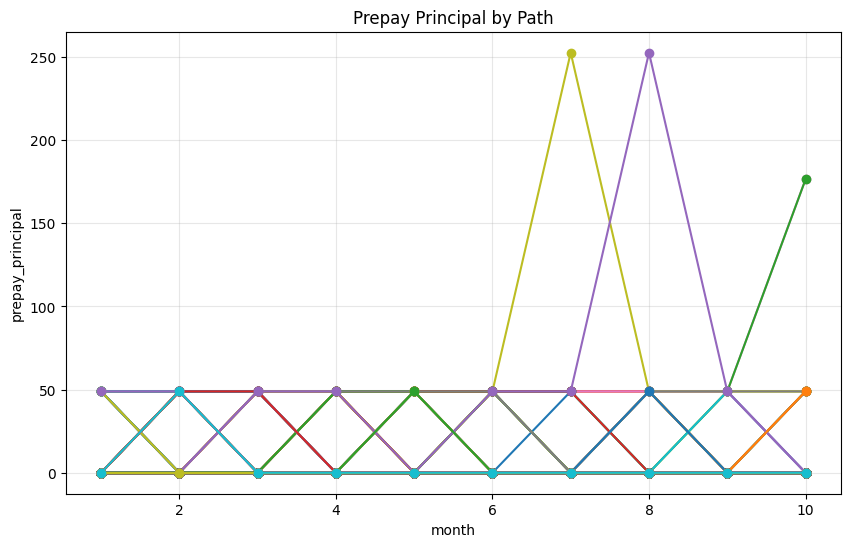

In [163]:
plot_monthly_prepay_distribution(prepays_path)# prepayment distribution on each month end, not cumulated